# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
quarter_map = {
    12:'1', 1:'1',2:'1',
    3:'2',4:'2',5:'2',
    6:'3',7:'3',8:'3',9:'3',
    10:'4',11:'4'
}

df['weather_season_india'] = df['date'].dt.month.map(quarter_map)

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [18]:
df.shape


(10886, 20)

В одному рядку містяться дані за одну годину.

In [20]:
df['date']

,date
datetime,
2011-01-01 00:00:00,2011-01-01
2011-01-01 01:00:00,2011-01-01
2011-01-01 02:00:00,2011-01-01
2011-01-01 03:00:00,2011-01-01
2011-01-01 04:00:00,2011-01-01
...,...
2012-12-19 19:00:00,2012-12-19
2012-12-19 20:00:00,2012-12-19
2012-12-19 21:00:00,2012-12-19


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


1. Заломи можуть бути через різкі перепади значень. Ми б могли відсортувати значення за зростанням або спаданням.
2. Помітно, що є пенвні спади на початку місяця та тенденція до зростання починаючи з другого тижня.
3. Так, це може бути вплив сезонних дощів, прохолоди.А також сонячні , теплі дні.
4. Вплив погодних умов - дощі, сильний вітер, туман, або навпаки - сонячний день, тепло. Вихідні та святкові дні також впливають, канікули, туристи. Можливі акції, реклама.


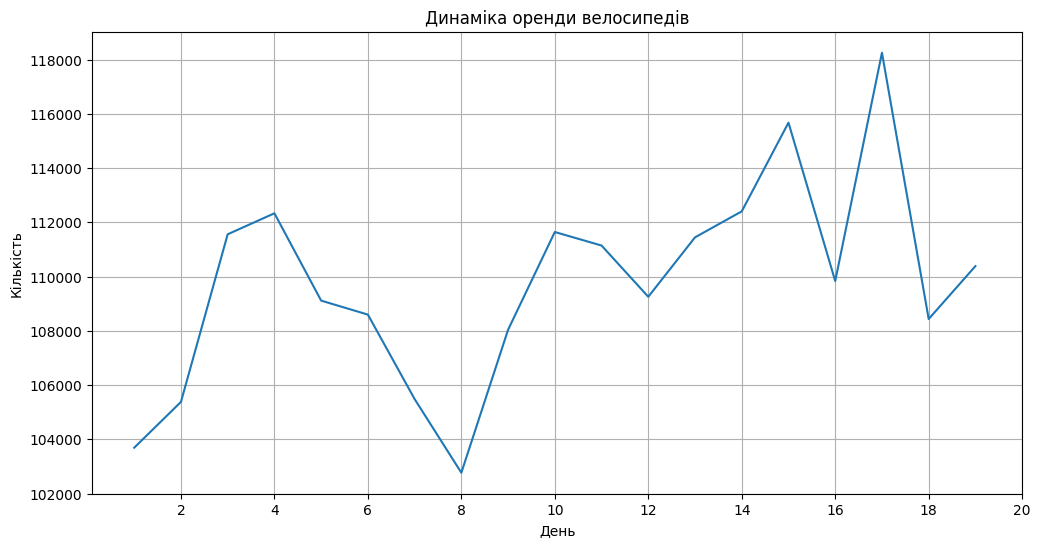

In [29]:
df.groupby(df.day)['count'].sum().plot(
   figsize=(12,6),
   title="Динаміка оренди велосипедів",
   ylabel='Кількість',
   xlabel='День',
   grid=True
   )

plt.xticks([2,4,6,8,10,12,14,16,18,20])
plt.show()


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

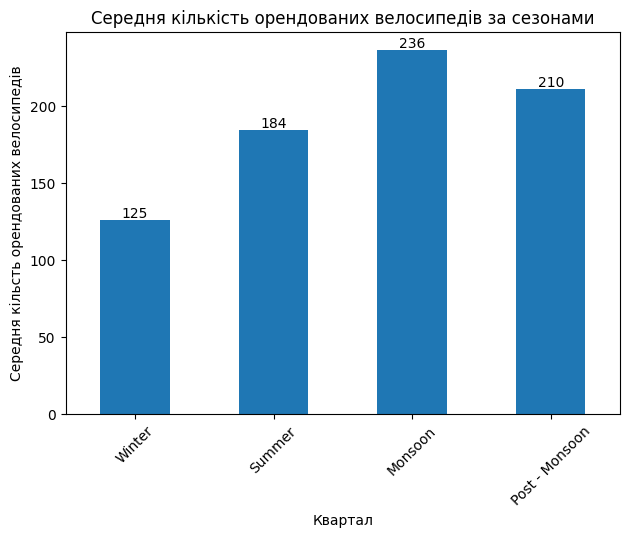

In [86]:
grouped = df.groupby('weather_season_india')['count'].mean()
ax = grouped.plot(kind='bar'),
figsize=(12,6)

for bar in plt.gca().patches:
  plt.text(
      bar.get_x() + bar.get_width()/2,
      bar.get_height(),
      str(int(bar.get_height())),
      ha='center',
      va='bottom'

  )

plt.ylabel('Середня кільсть орендованих велосипедів')
plt.xlabel('Квартал')
plt.title('Середня кількість орендованих велосипедів за сезонами')
plt.xticks(rotation=45)
plt.tight_layout()
plt.xticks([0,1,2,3],["Winter", "Summer","Monsoon", "Post - Monsoon" ])
plt.show()

1. Найбільша середня орендована кількість велосипедів в 3 квартал.

2. В Індії поділ сезонів дещо відрізняється від класичного. Тому 3 квартал - з червня по вересень. Цей період приносить сезонні вітри, що змінюють напрямок двічі на рік, та сезон дощів.
Тоді з чим може бути пов'язаний попит?

- ускладнення руху дорожнього транспорту через затори та затоплення, тому люди користуються більш гнучким - велосипедом.
- люди уникають переплат на таксі, на яке в період дощів підвищується попит, так значно дешевше.
- велосипед - це основний вид транспорту, люди використовують його для щоденного пересування по місту, щоб дістатися на роботу , навчання.
- дощі - це короткі зливи, між якими сухо.
- можлива стимуляція знижками , щоб в цей мусонний сезон не падав попит.

3. Відрізняються в 1.88 разів між Winter та Monsoon.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


1. Пік оренди спостерігаєтьсся в 6 місяці, а спад в - 1.
2. Спад спостерігається в зимовий період - це 12,1 та 2 місяці. А підйом 6-9 місяці, в період Monsoon. Так, закономірність збігається.
3. Клімат прямопропорційно впливає на кількість оренди. Адже в холодну погоду, сильні дощі , туман - попит падає. Люди або не орендують в цей період, або це мінімальна кількість орендованих велосипедів. А в теплий період року спостерігається - пік активності.

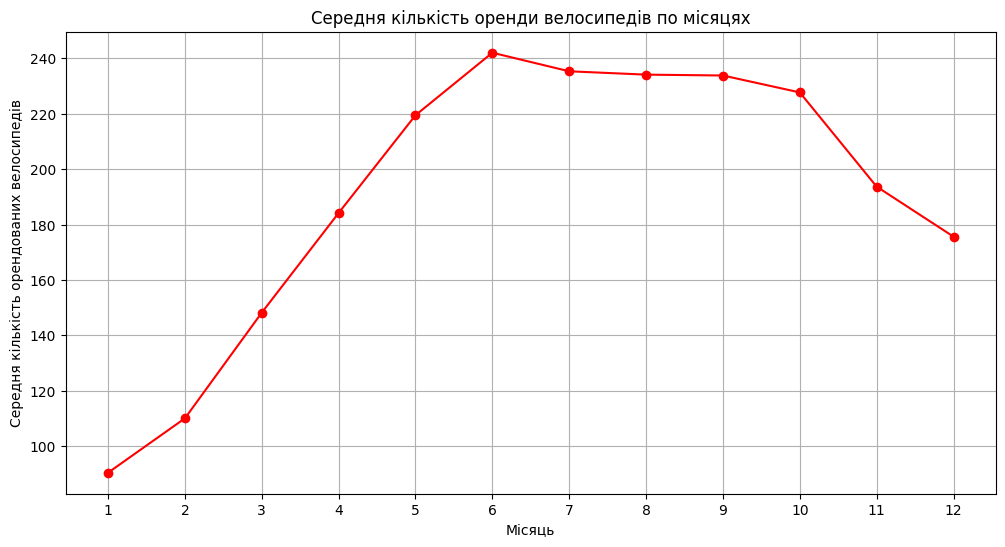

In [83]:
df.groupby(df.month)['count'].mean().plot(
    figsize=(12,6),
    marker='o',
    title='Середня кількість оренди велосипедів по місяцях',
    color='red',
    xlabel='Місяць',
    ylabel='Середня кількість орендованих велосипедів',
    grid=True
)

plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12])
plt.show()

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

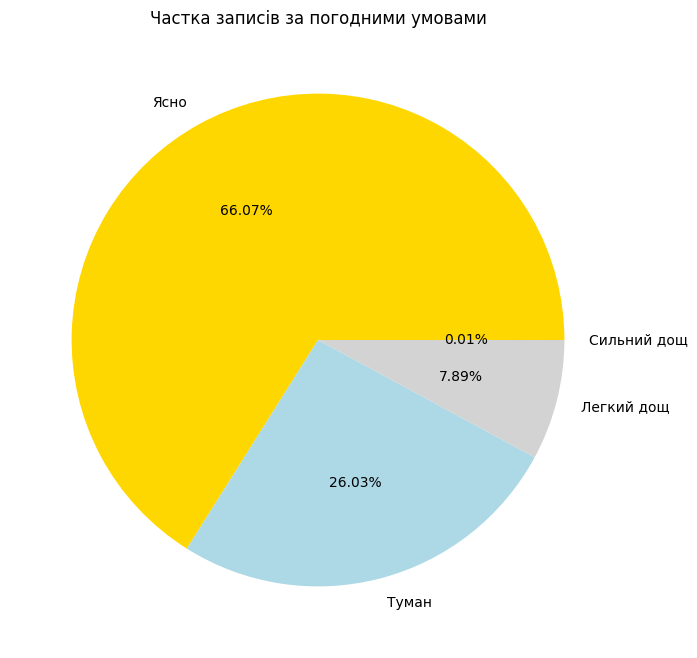

In [9]:
part_weather = df.groupby('weather')['weather'].count()

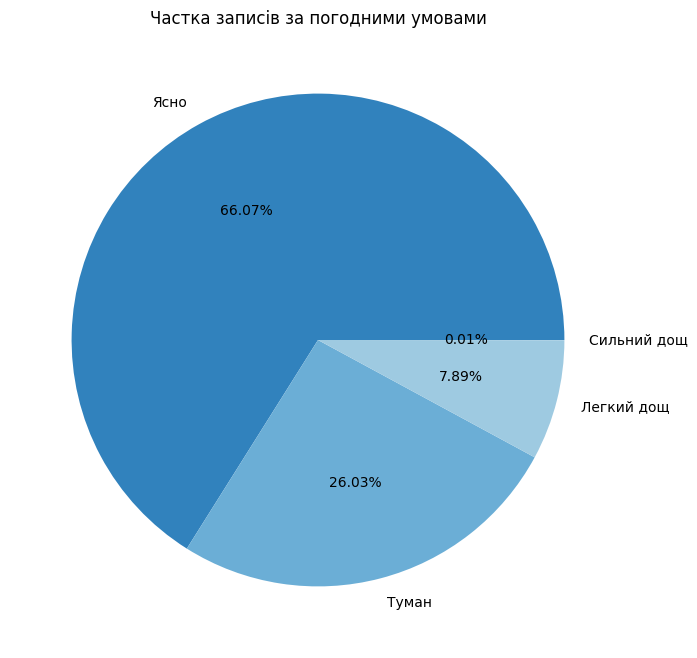

In [81]:
part_weather.plot.pie(
    figsize=(8,8),
    autopct='%1.2f%%',
    labels =['Ясно','Туман','Легкий дощ','Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=plt.cm.tab20c.colors

);


1. В датасеті переважає ясна погода.
2. Так , є дні із сильними дощем. Близько 0.01%, та звісно такої кількості даних не достатньо для повноцінного аналізу.
3. Погодні умови прямо впливають на кількість орендованих велосипедів. Ясна погода - це ідеальний час для велисипедистів, попит найбільший, люди хочуть проводити час на свіжому повітрі.
Туман - попит знижується та не зникає. Зменшується видимість - тому потрібно бути дуже обережним, більше ризику, сирість , що також викликає дискомфорт.
Легкий дощ - попит знижується, страх слизьких доріг.
Сильний дощ - попит мінімальний або відсутнй. Небезпечно на дорогах, слизько, велосипедист намокає, некомфортно. Люди обирають альтернативний транспорт.



## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

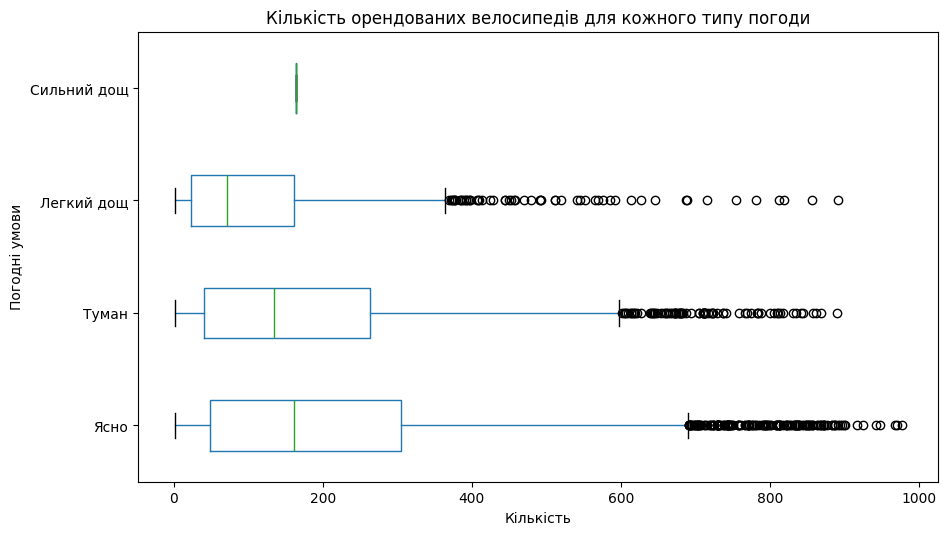

In [60]:
from numpy import array
df.boxplot(
    column='count',
    labels= ["g","j","k","l"],
    by='weather',
    figsize=(10,6),
    vert=False,
    grid=False
)

plt.title('Кількість орендованих велосипедів для кожного типу погоди')
plt.xlabel('Кількість')
plt.ylabel('Погодні умови')
plt.yticks([1,2,3,4],['Ясно','Туман','Легкий дощ','Сильний дощ'])
plt.suptitle('')
plt.show()

1. При ясній погоді найбільший розкид в кількості оренди орінтовно до 680 велосипедів.
2. Викиди присутні при ясній погоді, тумані та легкому дощі.
3. При ясній погодні медіанне значення навище, близько 170-180 орендованих велосипедів.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

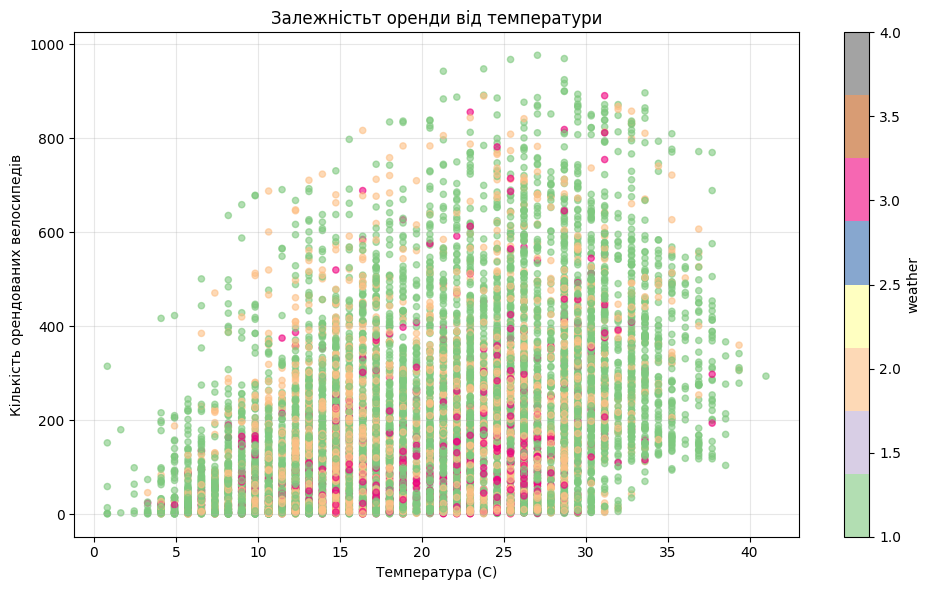

In [12]:
from IPython.core.pylabtools import figsize
df.plot.scatter(
    x='temp',
    y='count',
    figsize=(10,6),
    alpha=0.6,
    c='weather',
    cmap='Accent',
    title='Залежністьт оренди від температури',
    xlabel= 'Температура (С)',
    ylabel='Кількість орендованих велосипедів'
)
plt.grid(True,alpha=0.3)
plt.tight_layout();

Між температурою та кількість оренди існую звя'зок. Можемо помітити , що найбільша кількість велосипедів орендується в комфорних межах температур - це 15-17 і до 30 градусів за Цельсієм.
До 15 та після 30 градусів - ми помічаємо помітний спад, попит падає.
Також хочу звернути увагу, що погодні умови , класифіковані - "ясно","туман","легкий дощ","сильний дощ" , також мають свій вплив.
При ясній погоді користувачі активно користуються орендою, при тумані попит падає, а при легкому дощі кількість орендованих велосипедів ще зменшується.
При сильному дощі - попит відсутній.


## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [13]:
rent_by_weekday = df.groupby('weekday')[['casual','registered']].mean()

In [14]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
rent_by_weekday = rent_by_weekday.reindex(order)

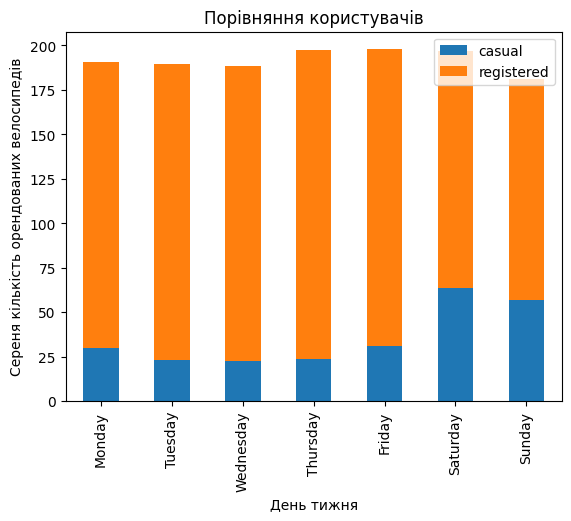

In [82]:
rent_by_weekday.plot(
    kind='bar',
    stacked=True
    )
plt.title('Порівняння користувачів')
plt.ylabel('Сереня кількість орендованих велосипедів')
plt.xlabel('День тижня');

1. Найбільше оренд від зареєстрованих користувачів в будні дні, з понеділка по п'ятницю.
2. В Індії багато людей може використовувати велосипед, щоб дістатися до роботи, школи, також це дешевий вид транспорту, не потрібно стояти в заторах. В будні дні люди працюють , навчаються в університетах, тому сервіс має постійний попит, молжливо користувачі придбали підписку, користуються регулярно.
Також оренда може бути актуальна для коротких поіздок, щоб доїхати до метро, пересування по центру міста на короткі дистанції, на території великих унівеситерів та компанії - для швидкого переміщення.
Якщо ми притримуємося такої гіпотези - то очевидно, що в вихідні попит падає.
Зробимо висновок, що сервіс з оренди велосипедів в Індії більш актуальний в будні дні - для робочих поїздок. На вихідних люди , можливо, лишаються вдома, відпочивають, не хочуть перебувати на спеці.